# MAL Analysis Project 
Created by TomPancakes

Importing Libraries 

In [211]:
import pandas as pd
import matplotlib.pyplot as plt


Creating pandas dataframe: Either using local json file, or by initiating API call via main.py. 

In [212]:
#import and run main.py (makes api request)
import os
import ast

if os.path.exists("anime.json"):
    df = pd.read_csv('anime.json')
    df['genres'] = df['genres'].apply(ast.literal_eval) #ensure genres column is stored as list
else: 
    import main #Run main python script only if no anime.json found
    df = pd.DataFrame(main.data_init())
    df.to_csv('anime.json', index=False)

pd.set_option('display.max_rows', None) #Make pandas show full tables unless specified
df.head(10) #Checking first 10 rows of dataframe



,id,title,averageScore,episodes,season,seasonYear,status,format,popularity,genres
0,16498,Attack on Titan,85,25.0,SPRING,2013.0,FINISHED,TV,977679,"[Action, Drama, Fantasy, Mystery]"
1,101922,Demon Slayer: Kimetsu no Yaiba,83,26.0,SPRING,2019.0,FINISHED,TV,925923,"[Action, Adventure, Drama, Fantasy, Supernatural]"
2,1535,Death Note,84,37.0,FALL,2006.0,FINISHED,TV,891203,"[Mystery, Psychological, Supernatural, Thriller]"
3,113415,JUJUTSU KAISEN,84,24.0,FALL,2020.0,FINISHED,TV,890900,"[Action, Drama, Supernatural]"
4,21459,My Hero Academia,77,13.0,SPRING,2016.0,FINISHED,TV,817876,"[Action, Adventure, Comedy]"
5,11061,Hunter x Hunter (2011),89,148.0,FALL,2011.0,FINISHED,TV,783448,"[Action, Adventure, Fantasy]"
6,21087,One-Punch Man,83,12.0,FALL,2015.0,FINISHED,TV,722475,"[Action, Comedy, Sci-Fi, Supernatural]"
7,20605,Tokyo Ghoul,76,12.0,SUMMER,2014.0,FINISHED,TV,691868,"[Action, Drama, Horror, Mystery, Psychological..."
8,20958,Attack on Titan Season 2,85,12.0,SPRING,2017.0,FINISHED,TV,686143,"[Action, Drama, Fantasy, Mystery]"
9,21,ONE PIECE,87,NaN,FALL,1999.0,RELEASING,TV,682334,"[Action, Adventure, Comedy, Drama, Fantasy]"


In [226]:
#Selection Practice: 
#Select by column
print(df["averageScore"][0]) #Select averagescore column. Then, grab 1st entry. 

#Select by row
print(df.loc[0], "\n") #Grab by index. (I.e., most popular show)
print(df.loc[df['title'] == "Frieren: Beyond Journey’s End"]) 



85
id                                          16498
title                             Attack on Titan
averageScore                                   85
episodes                                     25.0
season                                     SPRING
seasonYear                                 2013.0
status                                   FINISHED
format                                         TV
popularity                                 977679
genres          [Action, Drama, Fantasy, Mystery]
Name: 0, dtype: object 

        id                          title  averageScore  episodes season  \
67  154587  Frieren: Beyond Journey’s End            91      28.0   FALL   

    seasonYear    status format  popularity                       genres  
67      2023.0  FINISHED     TV      411240  [Adventure, Drama, Fantasy]  


### Genre Analysis

In [214]:
#average score by genre. 

# Dataset currently stores genres as a list of multiple genres.
# To compare individual genres, a new data frame will be created with individual entries for EACH genre of EACH show

df_exploded = df.explode('genres')

#Genre Scores
genre_scores = df_exploded.groupby('genres')['averageScore'].mean() #groupby 
print(genre_scores.sort_values(ascending=False), "\n")

#Genre Popularity
genre_popularity = df_exploded.groupby('genres')['popularity'].mean()
print(genre_popularity.sort_values(ascending=False))

genres
Music            79.590909
Sports           79.200000
Drama            78.123786
Psychological    78.111842
Thriller         77.954545
Mystery          77.093168
Mahou Shoujo     76.500000
Slice of Life    76.146617
Supernatural     76.090253
Sci-Fi           75.837349
Adventure        75.722022
Mecha            75.322581
Action           75.010267
Comedy           74.475584
Fantasy          74.349727
Romance          73.244505
Horror           72.928571
Ecchi            68.953846
Name: averageScore, dtype: float64 

genres
Thriller         219556.015152
Psychological    207975.151316
Drama            206370.444175
Horror           205909.517857
Supernatural     199816.339350
Mystery          197382.490683
Action           196577.583162
Adventure        196216.498195
Fantasy          179946.204918
Mecha            175565.870968
Sci-Fi           169678.951807
Comedy           166906.796178
Sports           165239.571429
Slice of Life    157003.236842
Romance          151136.31044

### Interpretation

Popularity:
- Popularity. 

Rating
- Firstly, it seems that higher rated genres tend to be more uncommon, where the lower rated genres are generally more common. For example, music, sports, drama are in the top 3, where action, comedy, fantasy, romance and horror are in the bottom segment. An interpretation of this could be that works in already saturated genres are seen as more generic and less standout. Whereabouts works which are in less crowded genres are seen as more unique and interesting.

- The genre of ecchi being the lowest rated is expected, as series with heavy fan service tend to be heavily criticised. Horror being also placed low is also interesting. Perhaps this suggests horror is difficult to translate into an animated medium like anime. 


### Quick Interesting Calculations

In [ ]:
avg_rating = df["averageScore"].mean() #Select by avgScore column (make into series), use pandas .mean() method
print(f"The average rating for all entries is: {avg_rating}\n" )
average_episode_count = df["episodes"].mean() #avg ep count
print(f"The average episode count among the 1000 entries is {average_episode_count} \n")
average_year = df["seasonYear"].mean() #avg year
print(f"The average year among the 1000 entries is {average_year}")


The average rating for all anime is: 75.387

The average episode count among the 1000 entries is 17.71943887775551 

The average year among the 1000 entries is 2016.1167002012073


### Popularity vs Rating Relatedness

The Person's correlation coeffcient between popularity & score is 0.34083650691868267


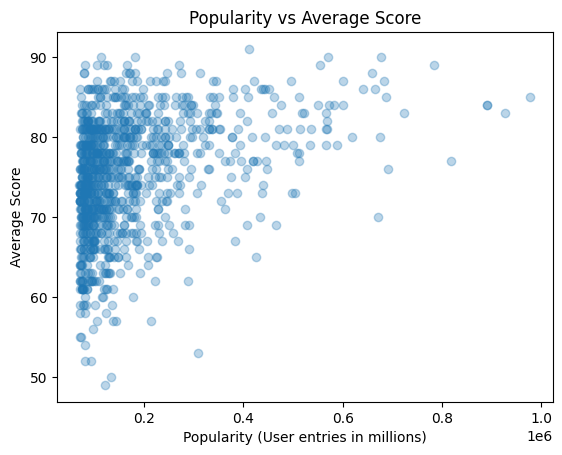

In [216]:
#Popularity vs Rating Relatedness

#Pearson correlation
pop_score_rval = df['popularity'].corr(df['averageScore'])
print(f"The Person's correlation coeffcient between popularity & score is {pop_score_rval}")

#Scatterplot
plt.scatter(df['popularity'], df['averageScore'], alpha=0.3)
plt.xlabel('Popularity (User entries in millions)')
plt.ylabel('Average Score')
plt.title('Popularity vs Average Score')
plt.show()


### Factors Affecting Ratings

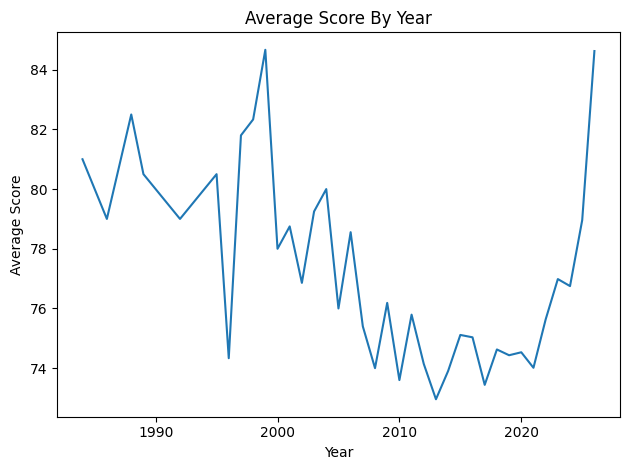

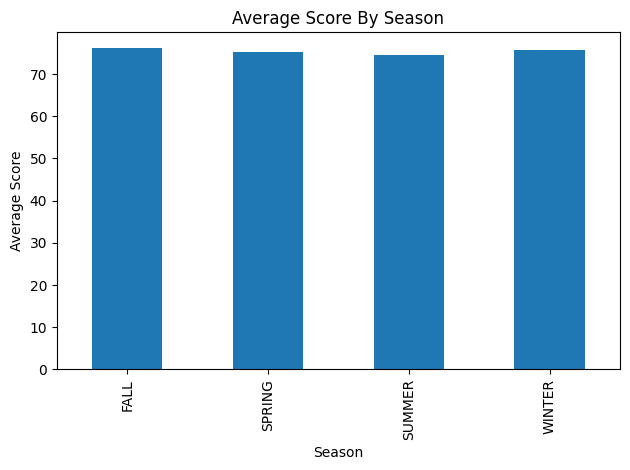

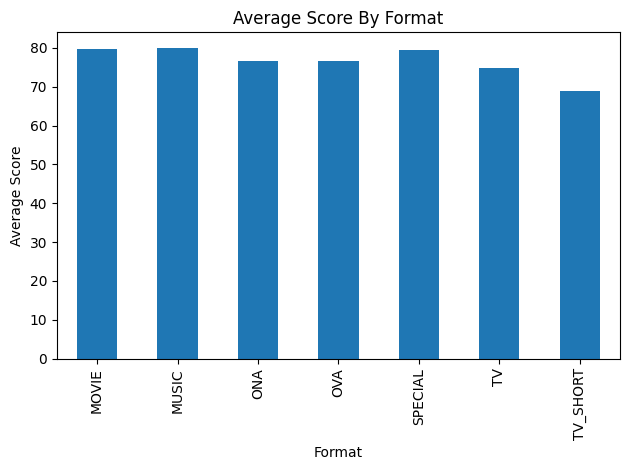

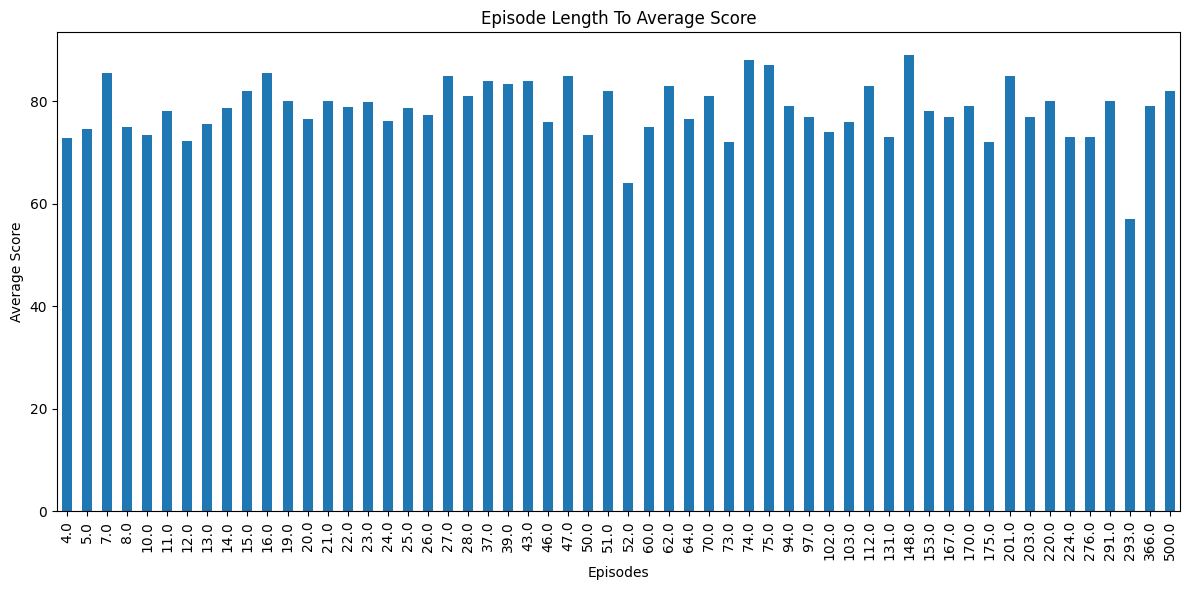

In [217]:
#Creation of score by year/season/format objects
score_by_year = df.groupby('seasonYear')['averageScore'].mean()
score_by_season = df.groupby('season')['averageScore'].mean()
score_by_format = df.groupby('format')['averageScore'].mean()

#Episode count vs rating. (DOESN'T ACCOUNT MULTIPLE SEASONS)
TV_format_df = df[df['format'] == 'TV'] #create new DF only including TV type (excludes movies + OVAS)
score_by_length = TV_format_df.groupby('episodes')['averageScore'].mean()

#Charts
score_by_year.plot(kind='line') #Year chart
plt.title('Average Score By Year')
plt.xlabel('Year')
plt.ylabel('Average Score')
plt.tight_layout()
plt.show()
score_by_season.plot(kind='bar') #Season chart
plt.title('Average Score By Season')
plt.xlabel('Season')
plt.ylabel('Average Score')
plt.tight_layout()
plt.show()
score_by_format.plot(kind='bar') #Format chart
plt.title('Average Score By Format')
plt.xlabel('Format')
plt.ylabel('Average Score')
plt.tight_layout()
plt.show()
score_by_length.plot(kind='bar', figsize=(12, 6)) #Episode Count
plt.title('Episode Length To Average Score')
plt.xlabel('Episodes')
plt.ylabel('Average Score')
plt.tight_layout()
plt.show()

### Interpretations
The graphs comparing the average ratings by Format (TV series, movie, etc), year of release, and season of release shows some interesting trends. 

**Year:** It seems that the year graph shows higher ratings for series further in the past, and a recent spike in anime closer to today. One might think that this suggests older anime is better perceived by viewers, but this is likely misleading. Firstly, the anilist platform came out in 2013, so anime from prior to this date are likely retrospective additions, and shows which have stood the test of time. This likely inflates scores compared to more recent entries which sees a broader range of anime. 

Another interesting detail from this graph is that it seems to 'bottom out' around the time the platform released. (Approx 2013-2014 on the graph). A conclusion which can be drawn from this is that the longer a series deviates from it's release (excluding pre 2013 entries), it's score lowers. Perhaps anime scores are affected by a recency bias? This idea is supported by the fact that the most recent anime (from 2026) show a peak in the graph. (similar in heigh the 1999ish peak). 

However, in recent years, anime production value has also been generally increasing. Perhaps this also means that the increase in more recent scores is not entirely due to recency bias. Rather than either or, I suspect both factors play a role in the higher scores in recent anime. 


**Season:** This graph is less telling. It shows that fall anime tend to fare the best, where summer anime the worst, although the difference is not significant. Perhaps this is due to fall being a season with higher TV viewership numbers in Japan, so studios release their more ambitious titles?

**Format:** This graph conveys fairly expected results. The movie, music, and special categorise fair the best. I can think of a few reasons for this. 
Movie- Higher production value than series (more condensed, higher budget for cinemas)
Music- Maybe they are made more commonly as passion projects vs commerical ventures. Also, low volume compared to other entries in the 1000 anime in dataset. 
Special- Cater to viewers who are already invested in a series. Thus, viewers are already likely to like the work. 

TV and TV_short fare the worst. TV- General series is the biggest category in the dataset. Lower production value than movies, and do not benefit from viewers already invested in the series like OVA/special. 
TV_SHORT- Often low-budget, short spin-offs. Not taken as seriously compared to main-series. Made as promotional material rather than storytelling, so scores reflect that. 


### Anime Popularity Analysis

In [218]:
#count popularity by year?
popularity_by_year = df.groupby('seasonYear')['popularity'].sum()
popularity_by_year.tail(10)
#This isn't very telling. Longer on the site = more entries. Not indicative of actual popularity.



seasonYear
2017.0    10513299
2018.0    12574276
2019.0    13752837
2020.0    10713515
2021.0    13561351
2022.0    10874016
2023.0     9504432
2024.0     6073524
2025.0     3337025
2026.0      960534
Name: popularity, dtype: int64

### Standard Deviation of specifc anime: 
(unimplemented)

In [219]:
#anime controversy can be calculated via standard deviation. oh right. how will i work that out...
#I see. I will... ugh. ye not practical for individual shows rn. 

#Skipping this code for now. Cool idea, but maybe for later version. 
is_implemented = False
if is_implemented:
    print("Would you like to calculate standard deviation (SD) of a particular show? (Y/N)")
    initiation = input() 
    if initiation == "Y":
        print("Please enter an anime which you want like to calculate the score Standard deviation of: ")
        anime_selected = input()
        try: 
            main.get_user_scores(anime_selected)
        except:
            print(f"Anime {anime_selected} not found!")
        
    print("Continuing with program")

In [220]:
print(df['format'][14:21]) #get format of 14-20th entry. 
df[['title', 'averageScore', 'popularity']].head(10)


14    MOVIE
15       TV
16       TV
17       TV
18       TV
19       TV
20       TV
Name: format, dtype: str


,title,averageScore,popularity
0,Attack on Titan,85,977679
1,Demon Slayer: Kimetsu no Yaiba,83,925923
2,Death Note,84,891203
3,JUJUTSU KAISEN,84,890900
4,My Hero Academia,77,817876
5,Hunter x Hunter (2011),89,783448
6,One-Punch Man,83,722475
7,Tokyo Ghoul,76,691868
8,Attack on Titan Season 2,85,686143
9,ONE PIECE,87,682334
